# SQL Data Analysis with Python in Jupyter Notebook

#### step 1: Install Required Libaries

In [1]:
!pip install pandas sqlalchemy plotly matplotlib

Defaulting to user installation because normal site-packages is not writeable


#### step 2: Reset & Connec to the SQLite Database

In [2]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
df = pd.read_csv("retail sales.csv")

In [10]:
df = pd.read_csv("retail sales.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4817,4818,CA-2015-139598,26/12/2015,31/12/2015,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Philadelphia,Pennsylvania,19134.0,East,OFF-AP-10003287,Office Supplies,Appliances,Tripp Lite TLP810NET Broadband Surge for Modem...,81.5520
4818,4819,CA-2015-139598,26/12/2015,31/12/2015,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Philadelphia,Pennsylvania,19134.0,East,OFF-ST-10001370,Office Supplies,Storage,Sensible Storage WireTech Storage Systems,227.1360
4819,4820,CA-2018-117436,08/06/2018,14/06/2018,Standard Class,LW-17125,Liz Willingham,Consumer,United States,Norwich,Connecticut,6360.0,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,10.3600
4820,4821,CA-2016-140025,07/04/2016,11/04/2016,Standard Class,PF-19120,Peter Fuller,Consumer,United States,San Antonio,Texas,78207.0,Central,OFF-AP-10002651,Office Supplies,Appliances,Hoover Upright Vacuum With Dirt Cup,463.2480


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4822 entries, 0 to 4821
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4822 non-null   int64  
 1   Order ID       4822 non-null   object 
 2   Order Date     4822 non-null   object 
 3   Ship Date      4822 non-null   object 
 4   Ship Mode      4822 non-null   object 
 5   Customer ID    4822 non-null   object 
 6   Customer Name  4822 non-null   object 
 7   Segment        4822 non-null   object 
 8   Country        4822 non-null   object 
 9   City           4822 non-null   object 
 10  State          4822 non-null   object 
 11  Postal Code    4821 non-null   float64
 12  Region         4822 non-null   object 
 13  Product ID     4822 non-null   object 
 14  Category       4822 non-null   object 
 15  Sub-Category   4822 non-null   object 
 16  Product Name   4822 non-null   object 
 17  Sales          4822 non-null   float64
dtypes: float

In [12]:
df = pd.DataFrame(df)
df.head()
column_list = list(df.columns)
column_list

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [13]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      1
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [15]:
df = df.dropna(subset = ["Postal Code"])

In [16]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [19]:
df.duplicated('Order ID').sum()

np.int64(2435)

In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.duplicated('Order ID').sum()

np.int64(2435)

In [23]:
df.drop_duplicates(subset = 'Order ID', inplace = True)
df.duplicated('Order ID').sum()

np.int64(0)

In [24]:
df.describe()

,Row ID,Postal Code,Sales
count,2386.000000,2386.000000,2386.000000
mean,2427.978625,54954.201593,214.625822
std,1377.971795,31672.677462,553.313915
min,1.000000,1040.000000,0.852000
25%,1270.250000,23498.500000,15.660000
50%,2431.500000,55407.000000,49.185000
75%,3607.750000,90004.000000,201.580000
max,4821.000000,99207.000000,11199.968000


In [9]:
df= pd.read_csv("retail sales.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4817,4818,CA-2015-139598,26/12/2015,31/12/2015,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Philadelphia,Pennsylvania,19134.0,East,OFF-AP-10003287,Office Supplies,Appliances,Tripp Lite TLP810NET Broadband Surge for Modem...,81.5520
4818,4819,CA-2015-139598,26/12/2015,31/12/2015,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Philadelphia,Pennsylvania,19134.0,East,OFF-ST-10001370,Office Supplies,Storage,Sensible Storage WireTech Storage Systems,227.1360
4819,4820,CA-2018-117436,08/06/2018,14/06/2018,Standard Class,LW-17125,Liz Willingham,Consumer,United States,Norwich,Connecticut,6360.0,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,10.3600
4820,4821,CA-2016-140025,07/04/2016,11/04/2016,Standard Class,PF-19120,Peter Fuller,Consumer,United States,San Antonio,Texas,78207.0,Central,OFF-AP-10002651,Office Supplies,Appliances,Hoover Upright Vacuum With Dirt Cup,463.2480


In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Order Year"] = df["Order Date"].dt.year

df[["Order Date", "Order Year"]].head()


,Order Date,Order Year
0,2017-08-11,2017.0
1,2017-08-11,2017.0
2,2017-12-06,2017.0
3,2016-11-10,2016.0
4,2016-11-10,2016.0


In [12]:
# Outlier checking for sales using IQR
q1 = df["Sales"].quantile(0.25)
q3 = df["Sales"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)


Lower limit: -276.13025000000005
Upper limit: 504.93175


In [13]:
df['Sales'] = df['Sales'].clip(lower=0, upper=upper_limit)

In [14]:
df["Sales_outlier"] = (df["Sales"] < lower_limit) | (df["Sales"] > upper_limit)

outliers = df[df["Sales_outlier"] == True]
outliers.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Sales_outlier


In [15]:
print("Number of Sales outliers:", df["Sales_outlier"].sum())


Number of Sales outliers: 0


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

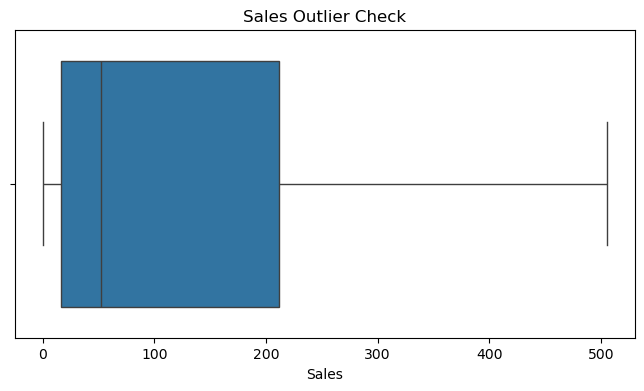

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Sales"])
plt.title("Sales Outlier Check")
plt.show()


In [21]:
# Optional: remove outliers
df_without_outliers = df[df["Sales_outlier"] == False]
df_without_outliers.shape


(4822, 20)

In [22]:
# Save cleaned data
df.to_csv("cleaned_data.csv", index=False)


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
# Make sure date columns are in datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Make sure sales is numeric
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")


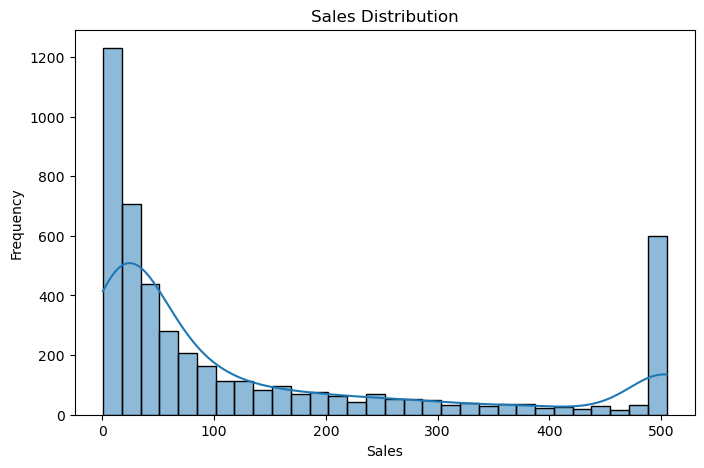

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


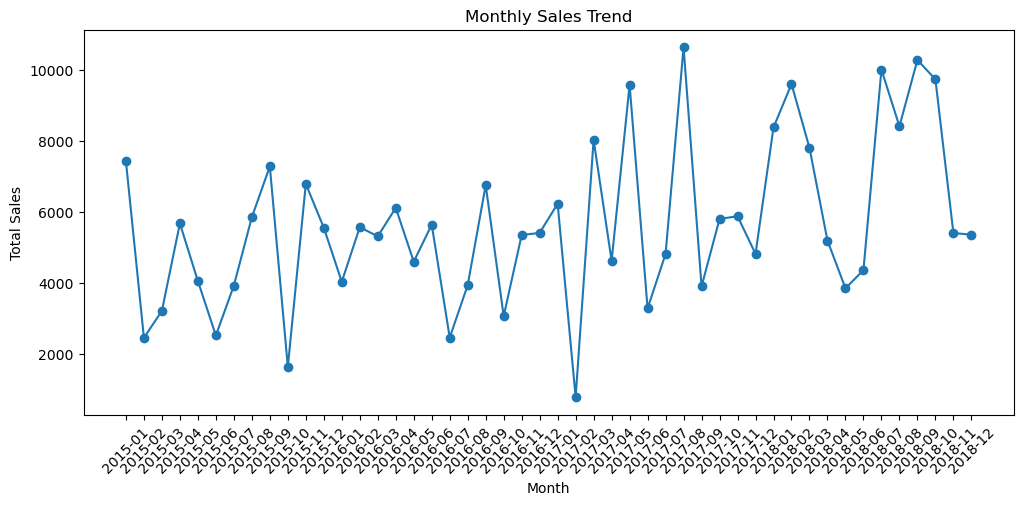

In [27]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


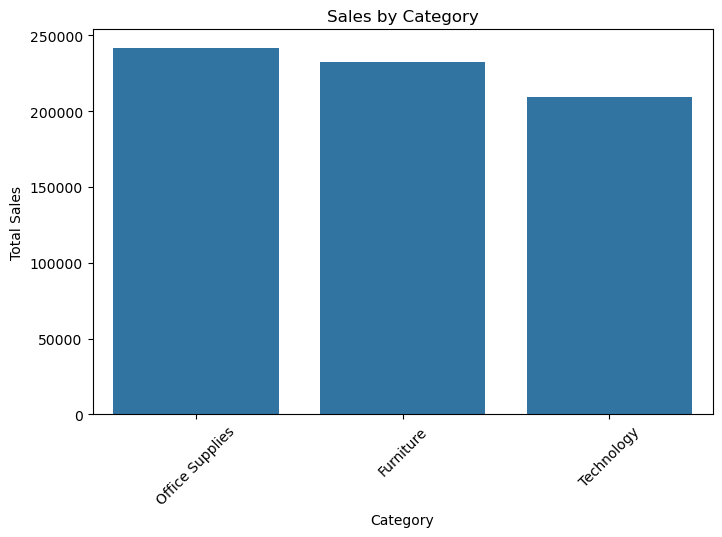

In [28]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


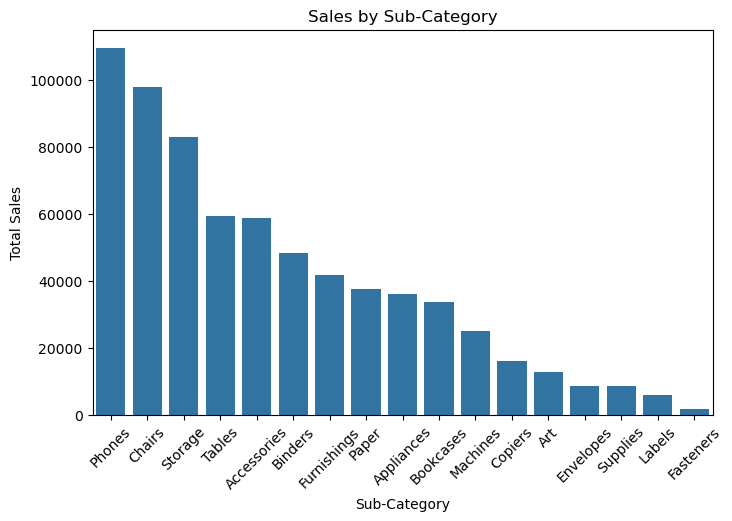

In [29]:
category_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


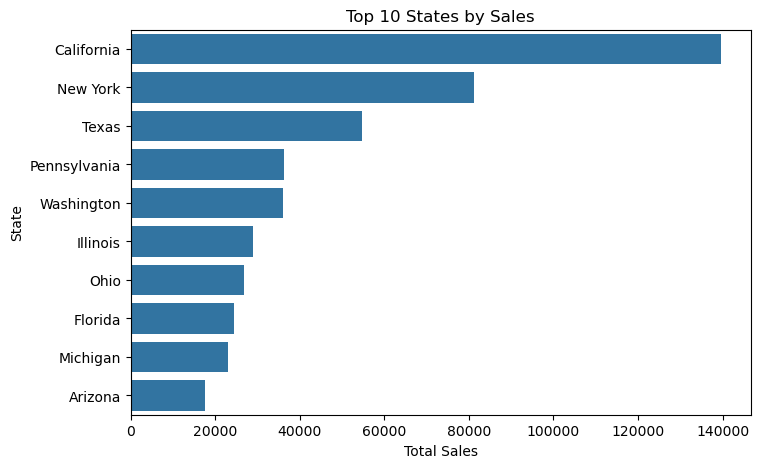

In [32]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_states.values, y=top_states.index)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()


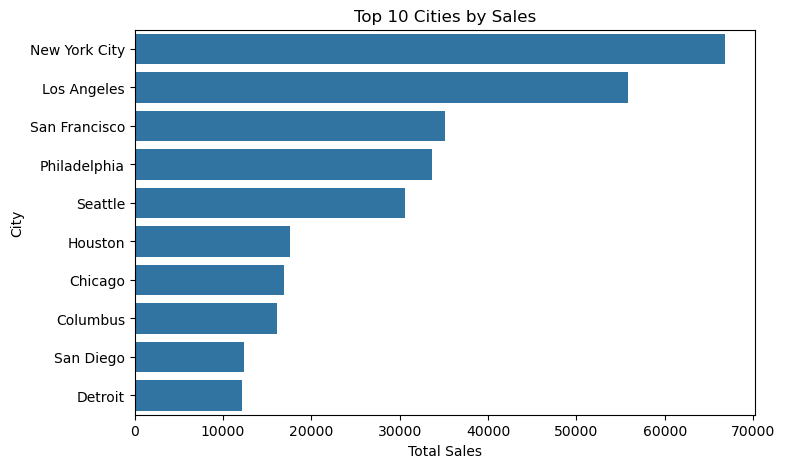

In [33]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_cities.values, y=top_cities.index)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()


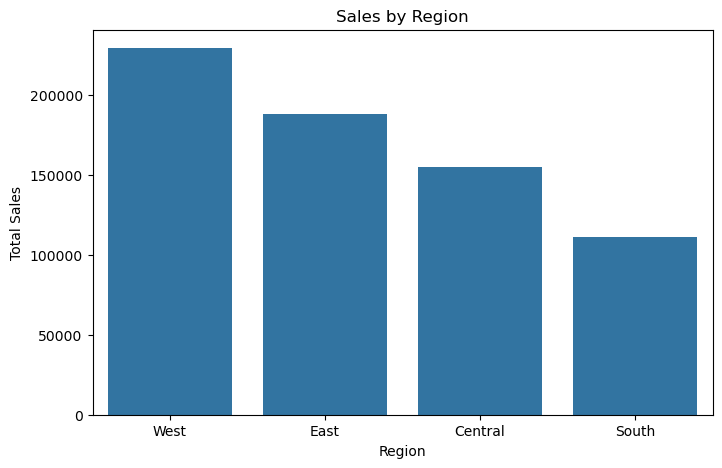

In [34]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


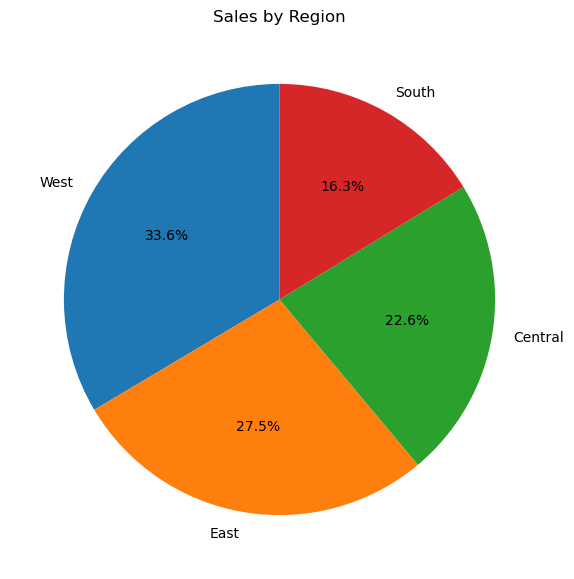

In [35]:
plt.figure(figsize=(7, 7))
plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Region")
plt.show()


In [36]:
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Delay"]].head()


,Order Date,Ship Date,Shipping Delay
0,2017-08-11,2017-11-11,92.0
1,2017-08-11,2017-11-11,92.0
2,2017-12-06,NaT,NaN
3,2016-11-10,NaT,NaN
4,2016-11-10,NaT,NaN


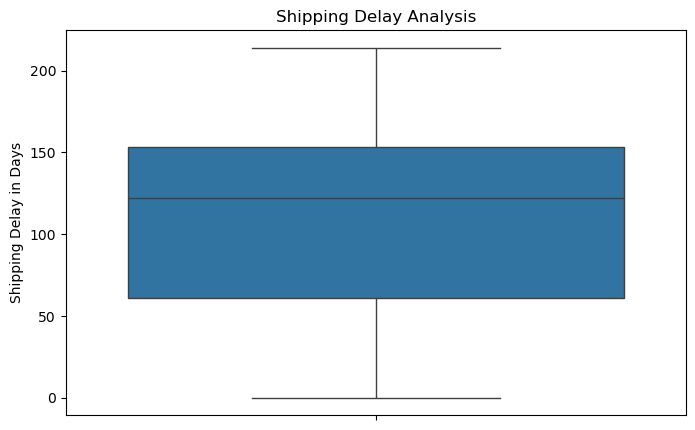

In [37]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Shipping Delay"])

plt.title("Shipping Delay Analysis")
plt.ylabel("Shipping Delay in Days")
plt.show()


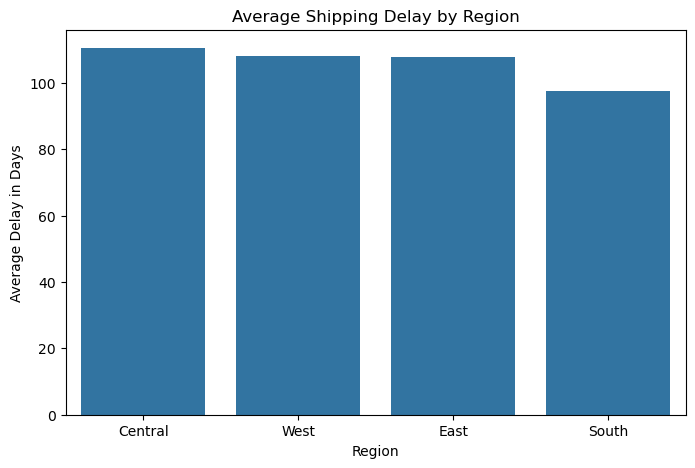

In [38]:
delay_by_region = df.groupby("Region")["Shipping Delay"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=delay_by_region.index, y=delay_by_region.values)

plt.title("Average Shipping Delay by Region")
plt.xlabel("Region")
plt.ylabel("Average Delay in Days")
plt.show()


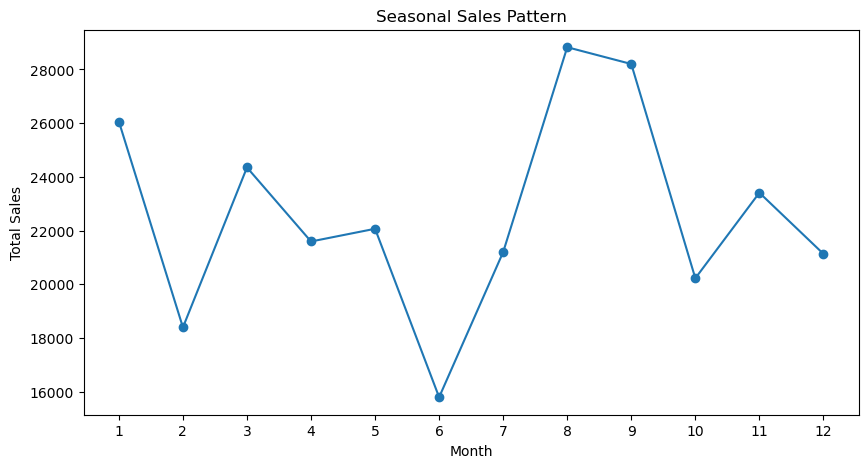

In [39]:
df["Order Month"] = df["Order Date"].dt.month

seasonal_sales = df.groupby("Order Month")["Sales"].sum()

plt.figure(figsize=(10, 5))
plt.plot(seasonal_sales.index, seasonal_sales.values, marker="o")

plt.title("Seasonal Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.show()


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [42]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

df = df.dropna(subset=["Order Date", "Sales"])
df = df.sort_values("Order Date")

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Sales_outlier,Shipping Delay,Order Month
540,541,CA-2015-140795,2015-01-02,2015-03-02,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,...,Central,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,468.90000,2015.0,False,59.0,1.0
157,158,CA-2015-104269,2015-01-03,2015-06-03,Second Class,DB-13060,Dave Brooks,Consumer,United States,Seattle,...,West,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,457.56800,2015.0,False,151.0,1.0
1372,1373,US-2015-157021,2015-01-04,2015-06-04,Second Class,KM-16720,Kunst Miller,Consumer,United States,Vallejo,...,West,OFF-LA-10002312,Office Supplies,Labels,Avery 490,29.60000,2015.0,False,151.0,1.0
1373,1374,US-2015-157021,2015-01-04,2015-06-04,Second Class,KM-16720,Kunst Miller,Consumer,United States,Vallejo,...,West,OFF-BI-10000042,Office Supplies,Binders,"Pressboard Data Binder, Crimson, 12"" X 8 1/2""",17.08800,2015.0,False,151.0,1.0
244,245,CA-2015-131926,2015-01-06,2015-06-06,Second Class,DW-13480,Dianna Wilson,Home Office,United States,Lakeville,...,Central,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,504.93175,2015.0,False,151.0,1.0


In [60]:
monthly_sales = df.set_index("Order Date").resample("ME")["Sales"].sum()

monthly_sales.head()


Order Date
2015-01-31    7426.65775
2015-02-28    2451.09775
2015-03-31    3211.16650
2015-04-30    5672.64300
2015-05-31    4052.14450
Freq: ME, Name: Sales, dtype: float64

In [61]:
monthly_sales = monthly_sales.fillna(0)

monthly_sales


Order Date
2015-01-31     7426.65775
2015-02-28     2451.09775
2015-03-31     3211.16650
2015-04-30     5672.64300
2015-05-31     4052.14450
2015-06-30     2517.57550
2015-07-31     3923.12025
2015-08-31     5847.90875
2015-09-30     7278.93575
2015-10-31     1631.72750
2015-11-30     6785.36875
2015-12-31     5552.65000
2016-01-31     4030.90300
2016-02-29     5566.74900
2016-03-31     5310.11700
2016-04-30     6112.34450
2016-05-31     4595.62125
2016-06-30     5640.48800
2016-07-31     2458.38575
2016-08-31     3934.93100
2016-09-30     6751.58075
2016-10-31     3062.86525
2016-11-30     5345.89700
2016-12-31     5407.46375
2017-01-31     6227.96675
2017-02-28      778.84800
2017-03-31     8029.26225
2017-04-30     4618.76625
2017-05-31     9574.55425
2017-06-30     3278.40550
2017-07-31     4814.69075
2017-08-31    10635.90175
2017-09-30     3897.23025
2017-10-31     5799.48325
2017-11-30     5876.33475
2017-12-31     4816.91225
2018-01-31     8375.68000
2018-02-28     9600.14200
2

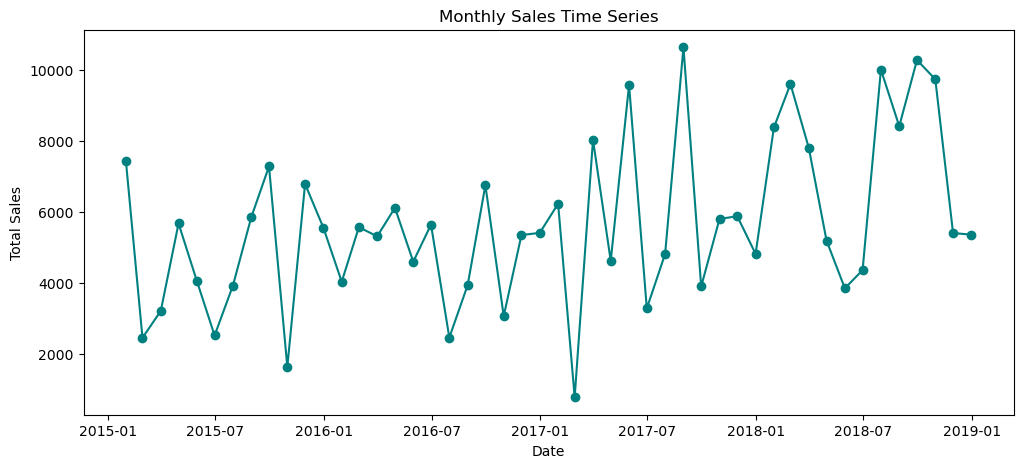

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="teal")

plt.title("Monthly Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


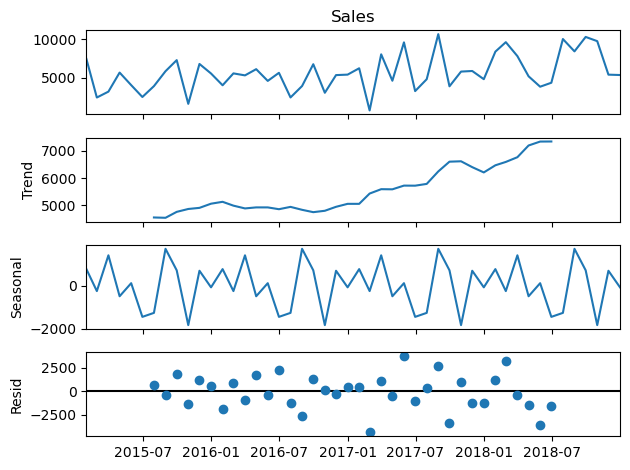

In [63]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()


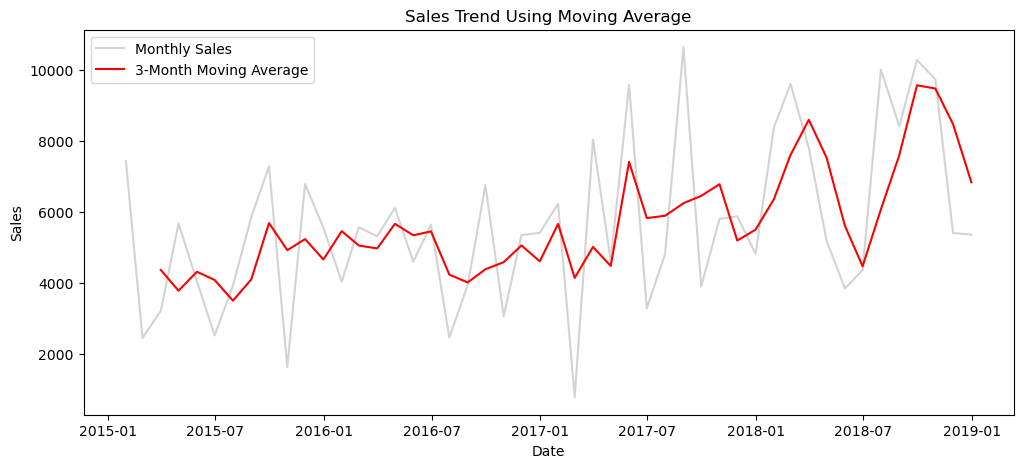

In [64]:
monthly_sales_ma = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, label="Monthly Sales", color="lightgray")
plt.plot(monthly_sales_ma, label="3-Month Moving Average", color="red")

plt.title("Sales Trend Using Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [65]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 36
Test size: 12


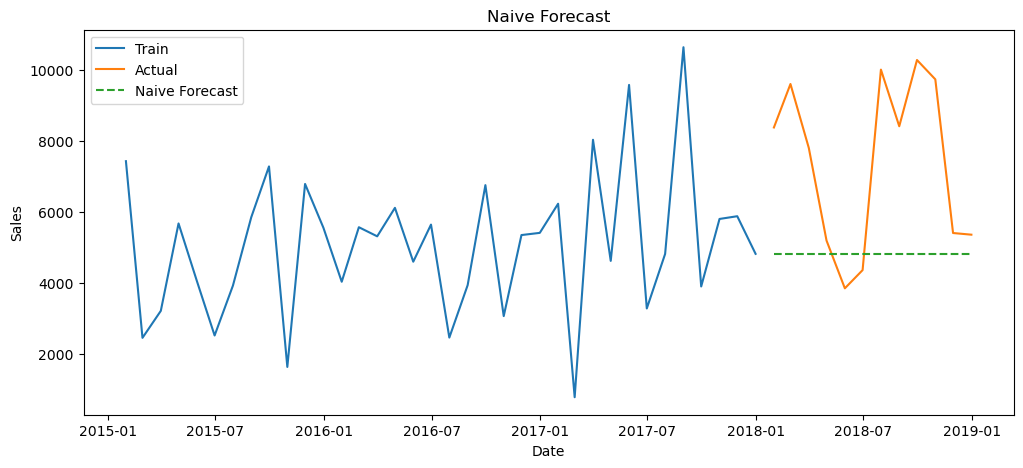

In [66]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(naive_forecast, label="Naive Forecast", linestyle="--")

plt.title("Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


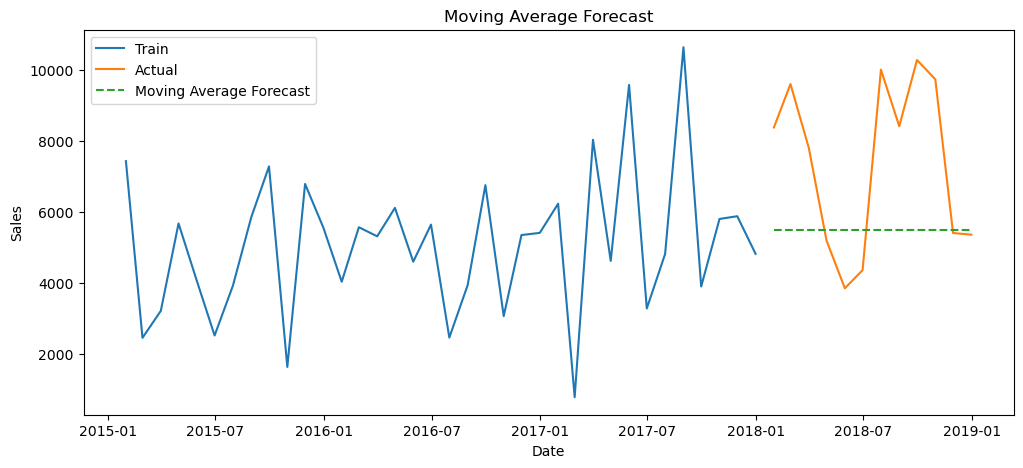

In [67]:
moving_avg_value = train.tail(3).mean()

moving_avg_forecast = pd.Series(
    moving_avg_value,
    index=test.index
)

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(moving_avg_forecast, label="Moving Average Forecast", linestyle="--")

plt.title("Moving Average Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


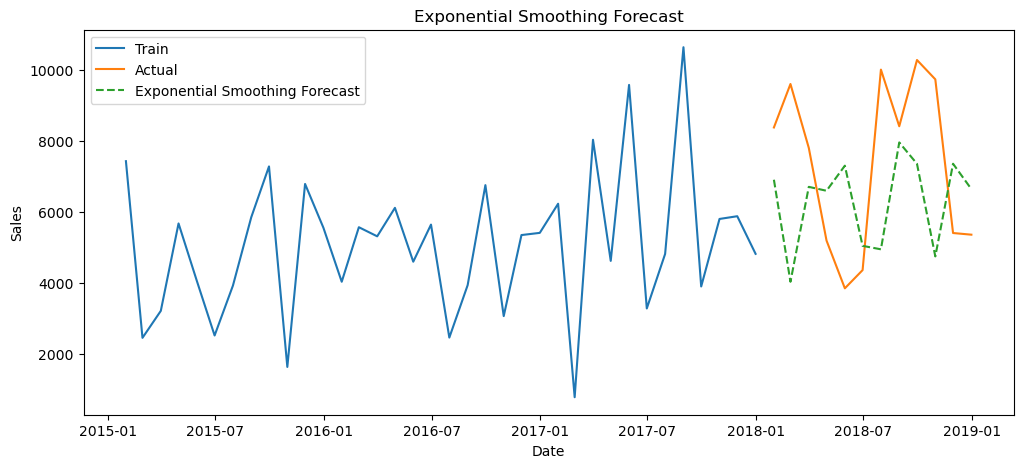

In [68]:
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit_model = model.fit()

exp_forecast = fit_model.forecast(12)

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(exp_forecast, label="Exponential Smoothing Forecast", linestyle="--")

plt.title("Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [69]:
def evaluate_forecast(actual, forecast, model_name):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print()


In [70]:
evaluate_forecast(test, naive_forecast, "Naive Forecast")
evaluate_forecast(test, moving_avg_forecast, "Moving Average Forecast")
evaluate_forecast(test, exp_forecast, "Exponential Smoothing")


Naive Forecast
MAE: 2784.234708333333
RMSE: 3417.676966503897

Moving Average Forecast
MAE: 2420.7955
RMSE: 2945.8136410762063

Exponential Smoothing
MAE: 2528.485821618747
RMSE: 3074.934496128381



In [71]:
final_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_fit = final_model.fit()

future_forecast = final_fit.forecast(12)

future_forecast


2019-01-31    8726.799149
2019-02-28    6810.318742
2019-03-31    8299.122642
2019-04-30    7610.096862
2019-05-31    7728.345927
2019-06-30    6159.893101
2019-07-31    7511.806832
2019-08-31    9418.477058
2019-09-30    9262.299670
2019-10-31    7267.474489
2019-11-30    8064.041374
2019-12-31    7494.905825
Freq: ME, dtype: float64

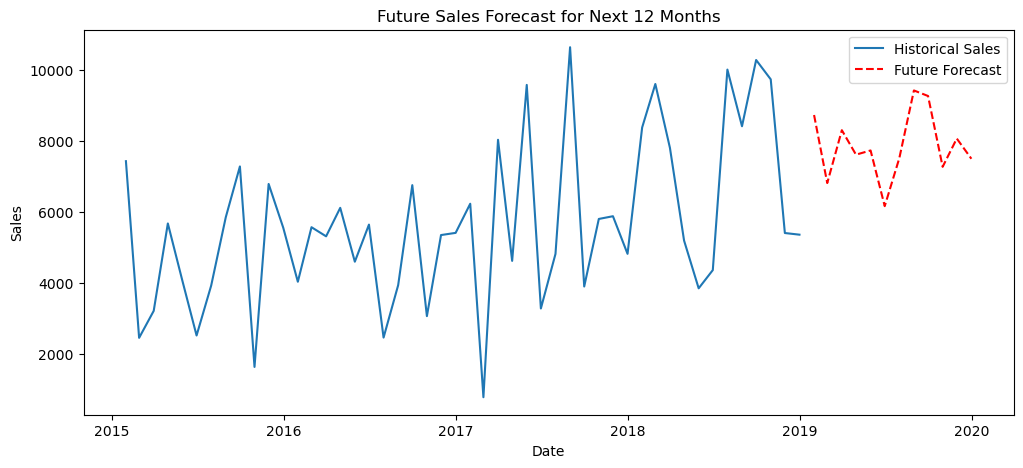

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, label="Historical Sales")
plt.plot(future_forecast, label="Future Forecast", linestyle="--", color="red")

plt.title("Future Sales Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [73]:
monthly_sales = (
    df.set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .fillna(0)
)


In [74]:
actual_vs_predicted = pd.DataFrame({
    "actual_sales": test,
    "predicted_sales": exp_forecast
})

actual_vs_predicted


,actual_sales,predicted_sales
2018-01-31,8375.68000,6903.605820
2018-02-28,9600.14200,4029.948682
2018-03-31,7800.86825,6703.459393
2018-04-30,5190.82950,6593.167419
2018-05-31,3845.91600,7299.822551
2018-06-30,4358.75750,5042.122492
2018-07-31,10005.63300,4944.245156
2018-08-31,8410.07150,7954.447434
2018-09-30,10276.17275,7352.570726
2018-10-31,9731.51300,4744.032405


In [75]:
actual_vs_predicted["error"] = (
    actual_vs_predicted["actual_sales"] 
    - actual_vs_predicted["predicted_sales"]
)

actual_vs_predicted["absolute_error"] = actual_vs_predicted["error"].abs()

actual_vs_predicted["percentage_error"] = (
    actual_vs_predicted["absolute_error"] 
    / actual_vs_predicted["actual_sales"]
) * 100

actual_vs_predicted


,actual_sales,predicted_sales,error,absolute_error,percentage_error
2018-01-31,8375.68000,6903.605820,1472.074180,1472.074180,17.575578
2018-02-28,9600.14200,4029.948682,5570.193318,5570.193318,58.021989
2018-03-31,7800.86825,6703.459393,1097.408857,1097.408857,14.067778
2018-04-30,5190.82950,6593.167419,-1402.337919,1402.337919,27.015681
2018-05-31,3845.91600,7299.822551,-3453.906551,3453.906551,89.807124
2018-06-30,4358.75750,5042.122492,-683.364992,683.364992,15.677977
2018-07-31,10005.63300,4944.245156,5061.387844,5061.387844,50.585384
2018-08-31,8410.07150,7954.447434,455.624066,455.624066,5.417600
2018-09-30,10276.17275,7352.570726,2923.602024,2923.602024,28.450300
2018-10-31,9731.51300,4744.032405,4987.480595,4987.480595,51.250824


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    actual_vs_predicted["actual_sales"],
    actual_vs_predicted["predicted_sales"]
)

mse = mean_squared_error(
    actual_vs_predicted["actual_sales"],
    actual_vs_predicted["predicted_sales"]
)

rmse = np.sqrt(mse)

r2 = r2_score(
    actual_vs_predicted["actual_sales"],
    actual_vs_predicted["predicted_sales"]
)

mape = actual_vs_predicted["percentage_error"].mean()

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAPE:", mape)


MAE: 2528.485821618747
MSE: 9455222.155480301
RMSE: 3074.934496128381
R2 Score: -0.818948050991986
MAPE: 34.82817764259354


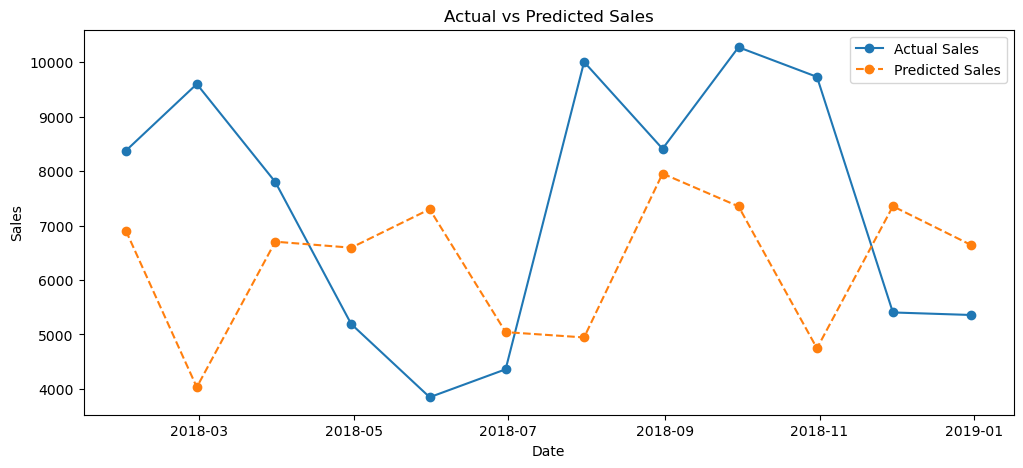

In [77]:
plt.figure(figsize=(12, 5))

plt.plot(
    actual_vs_predicted.index,
    actual_vs_predicted["actual_sales"],
    label="Actual Sales",
    marker="o"
)

plt.plot(
    actual_vs_predicted.index,
    actual_vs_predicted["predicted_sales"],
    label="Predicted Sales",
    marker="o",
    linestyle="--"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


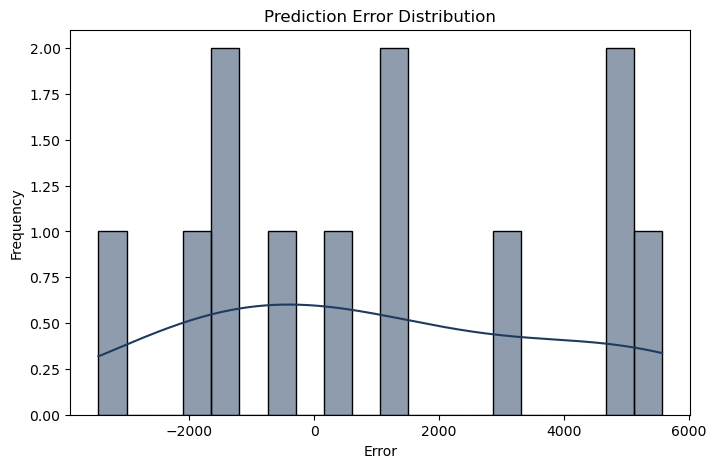

In [80]:
plt.figure(figsize=(8, 5))

sns.histplot(
    actual_vs_predicted["error"],
    bins=20,
    kde=True,
    color="#1F3A5F"
)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


In [2]:
import pandas as pd
df= pd.read_csv("retail sales.csv")
df
df.to_csv("cleaned_data_for_powerbi.csv", index=False)

In [3]:
import pandas as pd
df= pd.read_csv("retail sales.csv")
df
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [5]:
# Prepare monthly sales
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

monthly_sales = (
    df.dropna(subset=["Order Date", "Sales"])
      .set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .fillna(0)
)

In [6]:
# Build forecast model
model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit_model = model.fit()

# Forecast next 12 months
future_forecast = fit_model.forecast(12)

In [7]:
# Convert forecast to CSV table
forecast_df = future_forecast.reset_index()
forecast_df.columns = ["forecast_month", "forecast_sales"]

forecast_df

,forecast_month,forecast_sales
0,2019-01-31,15794.878353
1,2019-02-28,9981.884437
2,2019-03-31,12413.592629
3,2019-04-30,12951.450107
4,2019-05-31,9395.699495
5,2019-06-30,8151.878518
6,2019-07-31,10467.241924
7,2019-08-31,17070.950779
8,2019-09-30,12666.187736
9,2019-10-31,8343.210903


In [8]:
# Save forecast CSV file
forecast_df.to_csv("sales_forecast.csv", index=False)

In [9]:
import os
os.listdir()

['.anaconda',
 '.cache',
 '.codex',
 '.conda',
 '.continuum',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.python_history',
 '.spss',
 '.vscode',
 'actual_vs_predicted_sales.csv',
 'AppData',
 'Application Data',
 'cd',
 'cleaned_data.csv',
 'cleaned_data_for_powerbi.csv',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'mentalmentor',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'Newfolder',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{cbdb9b9d-fcba-11ef-b58b-fe11472176d7}.TM.blf',
 'NTUSER.DAT{cbdb9b9d-fcba-11ef-b58b-fe11472176d7}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{cbdb9b9d-fcba-11ef-b58b-fe11472176d7}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'retail sales.csv',
 'retail sales.ipynb',
 'sales.ipynb',
 'sales_forecast.csv',
 'Saved Games',
 'Searches'

In [11]:
import pandas as pd
df= pd.read_csv("retail sales.csv")
df


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4817,4818,CA-2015-139598,26/12/2015,31/12/2015,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Philadelphia,Pennsylvania,19134.0,East,OFF-AP-10003287,Office Supplies,Appliances,Tripp Lite TLP810NET Broadband Surge for Modem...,81.5520
4818,4819,CA-2015-139598,26/12/2015,31/12/2015,Standard Class,MG-17695,Maureen Gnade,Consumer,United States,Philadelphia,Pennsylvania,19134.0,East,OFF-ST-10001370,Office Supplies,Storage,Sensible Storage WireTech Storage Systems,227.1360
4819,4820,CA-2018-117436,08/06/2018,14/06/2018,Standard Class,LW-17125,Liz Willingham,Consumer,United States,Norwich,Connecticut,6360.0,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,10.3600
4820,4821,CA-2016-140025,07/04/2016,11/04/2016,Standard Class,PF-19120,Peter Fuller,Consumer,United States,San Antonio,Texas,78207.0,Central,OFF-AP-10002651,Office Supplies,Appliances,Hoover Upright Vacuum With Dirt Cup,463.2480


In [12]:
# Prepare monthly sales
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

monthly_sales = (
    df.dropna(subset=["Order Date", "Sales"])
      .set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .fillna(0)
)

In [13]:
# Create 3-month moving average
moving_average = monthly_sales.rolling(window=3).mean()

In [14]:
# Convert to table
moving_average_df = moving_average.reset_index()
moving_average_df.columns = ["month", "moving_average_sales"]

moving_average_df

,month,moving_average_sales
0,2015-01-31,NaN
1,2015-02-28,NaN
2,2015-03-31,7172.272333
3,2015-04-30,5435.315667
4,2015-05-31,7265.072000
5,2015-06-30,7117.847000
6,2015-07-31,5307.374000
7,2015-08-31,7738.492333
8,2015-09-30,11274.743000
9,2015-10-31,10380.246000


In [15]:
# Save as CSV
moving_average_df.to_csv("moving_average_sales.csv", index=False)

In [16]:
import os
os.listdir()

['.anaconda',
 '.cache',
 '.codex',
 '.conda',
 '.continuum',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.python_history',
 '.spss',
 '.vscode',
 'actual_vs_predicted_sales.csv',
 'AppData',
 'Application Data',
 'cd',
 'cleaned_data.csv',
 'cleaned_data_for_powerbi.csv',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'mentalmentor',
 'Microsoft',
 'moving_average_sales.csv',
 'Music',
 'My Documents',
 'NetHood',
 'Newfolder',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{cbdb9b9d-fcba-11ef-b58b-fe11472176d7}.TM.blf',
 'NTUSER.DAT{cbdb9b9d-fcba-11ef-b58b-fe11472176d7}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{cbdb9b9d-fcba-11ef-b58b-fe11472176d7}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'retail sales.csv',
 'retail sales.ipynb',
 'sales.ipynb',
 'sales_forecast.csv'

In [6]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("retail sales.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

monthly_sales = (
    df.dropna(subset=["Order Date", "Sales"])
      .set_index("Order Date")
      .resample("M")["Sales"]
      .sum()
      .fillna(0)
)

train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit_model = model.fit()
exp_forecast = fit_model.forecast(12)

actual_vs_predicted = pd.DataFrame({
    "month": test.index,
    "actual_sales": test.values,
    "predicted_sales": exp_forecast.values
})

actual_vs_predicted.to_csv("actual_vs_predicted_sales.csv", index=False)

actual_vs_predicted

C:\Users\User\AppData\Local\Temp\ipykernel_20000\3050295183.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


,month,actual_sales,predicted_sales
0,2018-01-31,16966.4290,13091.986970
1,2018-02-28,14023.6660,4865.463149
2,2018-03-31,12571.7080,8478.631038
3,2018-04-30,14763.9090,9908.556439
4,2018-05-31,3845.9160,9713.549609
5,2018-06-30,4745.0388,6679.425913
6,2018-07-31,15759.4675,7219.068386
7,2018-08-31,18636.9900,14152.057860
8,2018-09-30,14244.8630,11397.958321
9,2018-10-31,13870.7100,6029.207737


In [8]:
actual_vs_predicted.to_csv("actual_vs_predicted_sales.csv", index=False)

In [9]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("retail sales.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [11]:
model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit_model = model.fit()

future_forecast = fit_model.forecast(12)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
df = pd.read_csv("retail sales.csv")

df.head()
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

df = df.dropna(subset=["Order Date", "Sales"])
df = df.sort_values("Order Date")

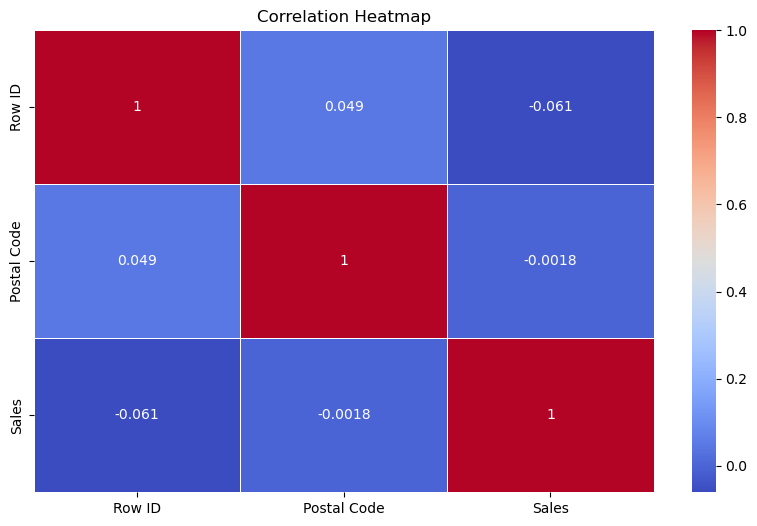

In [6]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_12992\951026597.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


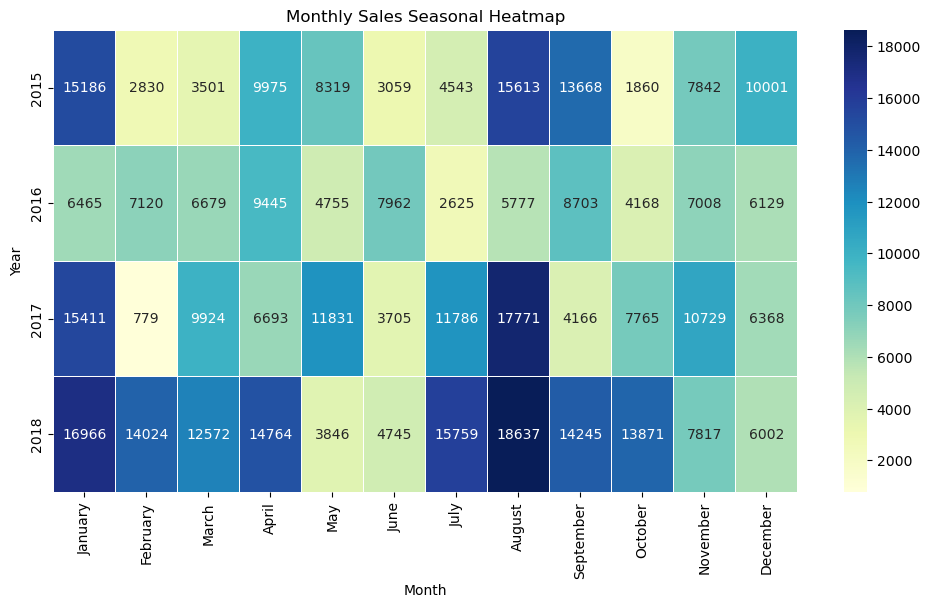

In [8]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("M")["Sales"]
      .sum()
      .fillna(0)
)

monthly_sales.head()
seasonal_df = monthly_sales.reset_index()
seasonal_df["year"] = seasonal_df["Order Date"].dt.year
seasonal_df["month"] = seasonal_df["Order Date"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

heatmap_data = seasonal_df.pivot(
    index="year",
    columns="month",
    values="Sales"
)

heatmap_data = heatmap_data[month_order]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Monthly Sales Seasonal Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

<Figure size 1000x500 with 0 Axes>

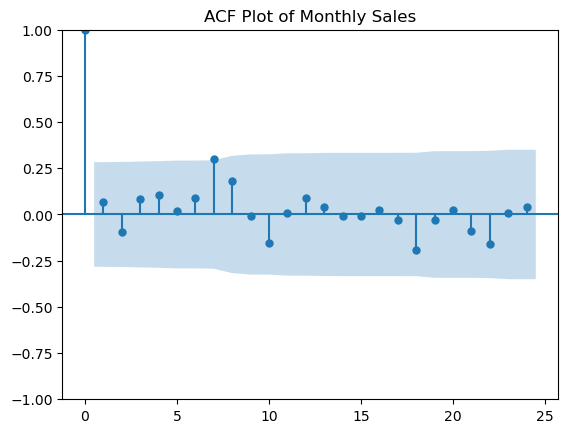

In [9]:
plt.figure(figsize=(10, 5))
plot_acf(monthly_sales, lags=24)
plt.title("ACF Plot of Monthly Sales")
plt.show()

<Figure size 1000x500 with 0 Axes>

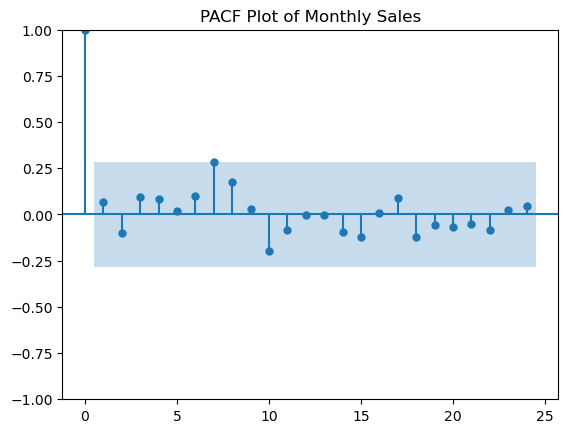

In [10]:
plt.figure(figsize=(10, 5))
plot_pacf(monthly_sales, lags=24, method="ywm")
plt.title("PACF Plot of Monthly Sales")
plt.show()

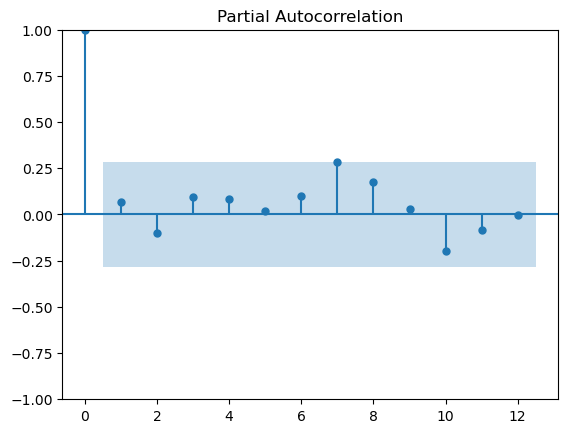

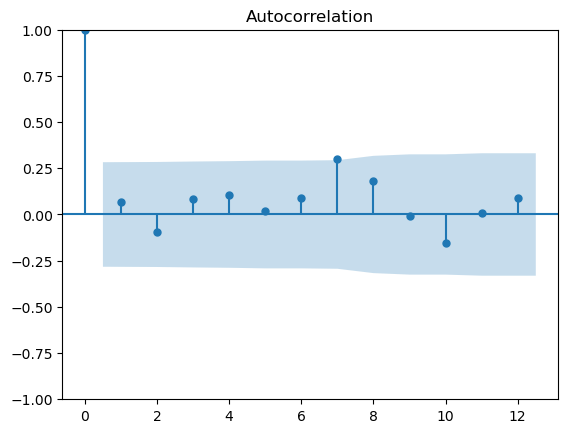

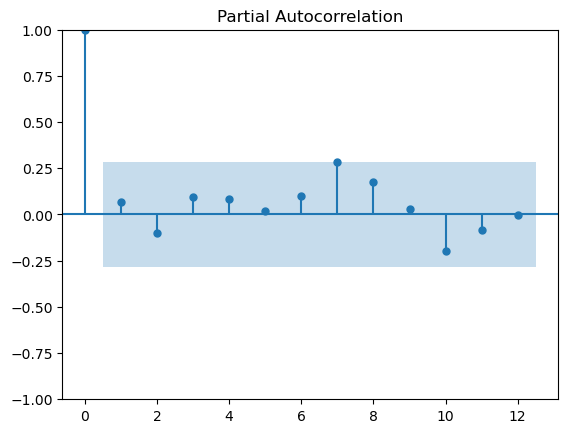

In [11]:
plot_acf(monthly_sales, lags=12)
plot_pacf(monthly_sales, lags=12, method="ywm")